In [1]:
import pandas as pd
df_origin = pd.read_csv(
    "comptages-routiers-permanents.csv", 
    #encoding = "latin-1",
    #nrows=10, 
    usecols=["Identifiant arc", "Date et heure de comptage", "Débit horaire","Taux d'occupation","Libelle", "geo_point_2d"],
    sep=';'
)
df_select = df_origin.head(30000)
df_select.head()


,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,geo_point_2d
0,5325,PE_Reuilly,2024-10-04T21:00:00+02:00,5955.0,18.70000,"48.83194119399435, 2.4051573651790856"
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03T14:00:00+01:00,NaN,24.60056,"48.815888020936654, 2.3587275983847618"
2,4010,Av_de_Clichy,2024-12-04T14:00:00+01:00,223.0,13.72667,"48.89143424973461, 2.3188079239898496"
3,1067,Quai_d'Issy,2025-01-11T19:00:00+01:00,769.0,4.43000,"48.839727155124635, 2.2702033361716216"
4,5460,SI_Passy,2025-02-18T22:00:00+01:00,NaN,NaN,"48.85791852282797, 2.26121220748304"


我们需要分析的包括：
是周几
是否是法国的公共假日或大型活动
是哪个月
是否是周末
是否是学生假日
是否是假日前（包括周末）
是否是假日后（包括周末）
属于哪个季节

Les facteurs que nous devons analyser sont les suivants :
Le jour de la semaine
S'il s'agit d'un jour férié français ou d'un événement majeur
Est-ce un jour férié scolaire ?
Le mois
S'il s'agit d'un week-end
S'il s'agit d'une période précédant un jour férié (week-ends compris)
S'il s'agit d'une période suivant un jour férié (week-ends compris)
La saison

In [2]:
import holidays

# 法国公共假日 jour fériés en France
fr_holidays = holidays.France()
print(fr_holidays)

{'country': FR, 'expand': True, 'language': None, 'market': None, 'observed': True, 'subdiv': None, 'years': set()}


In [3]:
import pandas as pd

MAJOR_EVENTS_PARIS_2025 = {
    "paris_marathon_2025": {"start": "2025-04-06", "end": "2025-04-06"},
    "paris_marathon_2026": {"start": "2026-04-12", "end": "2026-04-12"},
    "french_open": {
        "start": "2025-05-25",
        "end": "2025-06-08"
    },
    "fete_musique": {
        "start": "2025-06-21",
        "end": "2025-06-21"
    },
    "tour_de_france_final": {
        "start": "2025-07-27",
        "end": "2025-07-27"
    }
}

school_holidays_zone_c = [
    ("2024-10-19", "2024-11-03"),
    ("2024-12-21", "2025-01-05"),
    # Vacances d'hiver
    ("2025-02-15", "2025-03-02"),
    # Vacances de printemps
    ("2025-04-12", "2025-04-27"),
    # Vacances d'été
    ("2025-07-05", "2025-08-31"),
    # Vacances de la Toussaint
    ("2025-10-18", "2025-11-02"),
    # Vacances de Noël
    ("2025-12-20", "2026-01-04"),
    ("2026-02-21", "2026-03-08")
]


In [ ]:
import pandas as pd
df = df_select.copy()
#确保格式  Vérifiez le format
df['Date et heure de comptage'] = pd.to_datetime(
    df['Date et heure de comptage'],
    errors='coerce',  # 遇到无法解析的变成 NaT
    utc=True           # 带时区时间统一转 UTC
)
#获取日期  Date d'acquisition
n_before = len(df)
df = df.dropna(subset=['Date et heure de comptage']).copy()
n_after = len(df)
df["date"] = df["Date et heure de comptage"].dt.date
print(f"Nombre de lignes avant suppression: {n_before}")
print(f"Nombre de lignes supprimées: {n_after}")
# 判断是否公共假日  Vérifiez si c'est un jour férié
df["est_jour_ferie"] = df["date"].apply( lambda d: 1 if d in fr_holidays else 0
)

# 判断是否是大型活动日 Vérifiez s'il s'agit d'un jour d'événement majeur
def is_major_event(date, events):
    for event, period in events.items():
        start = pd.to_datetime(period["start"]).date()
        end = pd.to_datetime(period["end"]).date()
        if start <= date <= end:
            return 1
    return 0
df["est_evenement_majeur"] = df["date"].apply(
    lambda d: is_major_event(d, MAJOR_EVENTS_PARIS_2025)
)

# 判断是否是学生假日 Vérifiez s'il s'agit de vacances scolaires
def is_school_holiday(date, holidays):
    for start_str, end_str in holidays:
        start = pd.to_datetime(start_str).date()
        end = pd.to_datetime(end_str).date()
        if start <= date <= end:
            return 1
    return 0
df['est_vacances_scolaires'] = df['date'].apply(
    lambda d: is_school_holiday(d, school_holidays_zone_c)
)
#判断是否是周末 Vérifiez si c'est weekend
df["est_weekend"] = df["Date et heure de comptage"].dt.weekday >= 5

#判断是否是（假期或大型活动日或周末）的前后一天
df["date"] = df["Date et heure de comptage"].dt.floor('D')  # datetime64[ns]
#Vérifiez s'il s'agit du jour avant ou après (jour férié, événement majeur ou week-end)
def generate_day_before_after(df, column_name):
    event_dates = df.loc[df[column_name] == 1, 'date'].drop_duplicates().sort_values()
    
    if event_dates.empty:
        df[f'{column_name}_day_before'] = 0
        df[f'{column_name}_day_after'] = 0
        return
    event_dates_set = set(event_dates)  # Timestamp set
    day_before_dates = set(event_dates - pd.Timedelta(days=1)) - event_dates_set
    day_after_dates  = set(event_dates + pd.Timedelta(days=1)) - event_dates_set

    df[f'{column_name}_day_before'] = df['date'].isin(day_before_dates).astype(int)
    df[f'{column_name}_day_after']  = df['date'].isin(day_after_dates).astype(int)

generate_day_before_after(df, 'est_weekend')
generate_day_before_after(df, 'est_jour_ferie')
generate_day_before_after(df, 'est_evenement_majeur')
generate_day_before_after(df, 'est_vacances_scolaires')

#获取周几，月份以及季节特征 Récupérer le jour de la semaine, le mois et les caractéristiques saisonnières
df["weekday"] = df["Date et heure de comptage"].dt.weekday
df["mois"] = df["Date et heure de comptage"].dt.month
def get_saison(month):
    if month in [12, 1, 2]:
        return "hiver"
    elif month in [3, 4, 5]:
        return "printemps"
    elif month in [6, 7, 8]:
        return "été"
    else:
        return "automne"

df["saison"] = df["mois"].apply(get_saison)

Nombre de lignes avant suppression: 30000
Nombre de lignes supprimées: 30000
datetime64[ns, UTC]
{Timestamp('2025-11-01 00:00:00+0000', tz='UTC'), Timestamp('2025-08-09 00:00:00+0000', tz='UTC'), Timestamp('2025-11-02 00:00:00+0000', tz='UTC'), Timestamp('2025-08-03 00:00:00+0000', tz='UTC'), Timestamp('2025-03-01 00:00:00+0000', tz='UTC'), Timestamp('2025-01-11 00:00:00+0000', tz='UTC'), Timestamp('2024-11-03 00:00:00+0000', tz='UTC'), Timestamp('2025-05-03 00:00:00+0000', tz='UTC')}
{Timestamp('2025-02-28 00:00:00+0000', tz='UTC'), Timestamp('2025-08-08 00:00:00+0000', tz='UTC'), Timestamp('2025-05-02 00:00:00+0000', tz='UTC'), Timestamp('2025-01-10 00:00:00+0000', tz='UTC'), Timestamp('2024-11-02 00:00:00+0000', tz='UTC'), Timestamp('2025-08-02 00:00:00+0000', tz='UTC'), Timestamp('2025-10-31 00:00:00+0000', tz='UTC')}
50
datetime64[ns, UTC]
{Timestamp('2025-11-01 00:00:00+0000', tz='UTC')}
{Timestamp('2025-10-31 00:00:00+0000', tz='UTC')}
0
datetime64[ns, UTC]
{Timestamp('2025-06-0

In [5]:

df.head()

,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,geo_point_2d,date,est_jour_ferie,est_evenement_majeur,est_vacances_scolaires,...,est_weekend_day_after,est_jour_ferie_day_before,est_jour_ferie_day_after,est_evenement_majeur_day_before,est_evenement_majeur_day_after,est_vacances_scolaires_day_before,est_vacances_scolaires_day_after,weekday,mois,saison
0,5325,PE_Reuilly,2024-10-04 19:00:00+00:00,5955.0,18.70000,"48.83194119399435, 2.4051573651790856",2024-10-04 00:00:00+00:00,0,0,0,...,0,0,0,0,0,0,0,4,10,automne
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03 13:00:00+00:00,NaN,24.60056,"48.815888020936654, 2.3587275983847618",2024-11-03 00:00:00+00:00,0,0,1,...,0,0,0,0,0,0,0,6,11,automne
2,4010,Av_de_Clichy,2024-12-04 13:00:00+00:00,223.0,13.72667,"48.89143424973461, 2.3188079239898496",2024-12-04 00:00:00+00:00,0,0,0,...,0,0,0,0,0,0,0,2,12,hiver
3,1067,Quai_d'Issy,2025-01-11 18:00:00+00:00,769.0,4.43000,"48.839727155124635, 2.2702033361716216",2025-01-11 00:00:00+00:00,0,0,0,...,0,0,0,0,0,0,0,5,1,hiver
4,5460,SI_Passy,2025-02-18 21:00:00+00:00,NaN,NaN,"48.85791852282797, 2.26121220748304",2025-02-18 00:00:00+00:00,0,0,1,...,0,0,0,0,0,0,0,1,2,hiver


In [7]:
summary_weekend = (
    df
    .groupby('est_weekend')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_weekend


,est_weekend,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,False,12077,642.023913,320.0,175.0,561.00,12678,8.441677,4.263055,1.788895,10.051253
1,True,3360,774.043065,344.5,176.0,566.25,3391,7.800439,4.142220,1.679725,9.200835


In [8]:
summary_jour_ferie = (
    df
    .groupby('est_jour_ferie')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_jour_ferie


,est_jour_ferie,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,0,14951,678.383419,324.0,174.0,561.00,15596,8.325957,4.26056,1.759302,9.954302
1,1,486,436.207819,361.5,215.0,578.75,473,7.660131,3.79000,2.043340,7.923330


In [9]:
summary_vacances_scolaires = (
    df
    .groupby('est_vacances_scolaires')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_vacances_scolaires


,est_vacances_scolaires,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,0,10951,726.714181,332.2,172.0,590.0,11637,8.601869,4.28945,1.718890,10.440560
1,1,4486,534.164177,311.5,180.0,498.0,4432,7.530442,4.10389,1.898192,8.618335


In [10]:
summary_evenement_majeur = (
    df
    .groupby('est_evenement_majeur')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
summary_evenement_majeur


,est_evenement_majeur,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,0,14246,685.273073,324.0,176.0,563.0,14896,8.234825,4.19834,1.763193,9.766807
1,1,1191,497.151385,340.0,169.0,549.5,1173,9.214767,5.11611,1.846110,11.035000


<Figure size 600x400 with 0 Axes>

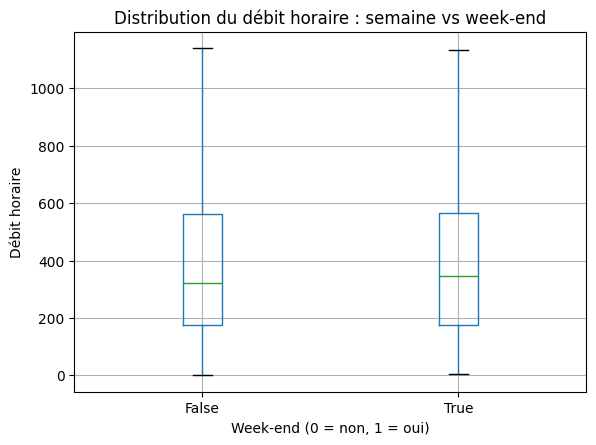

<Figure size 600x400 with 0 Axes>

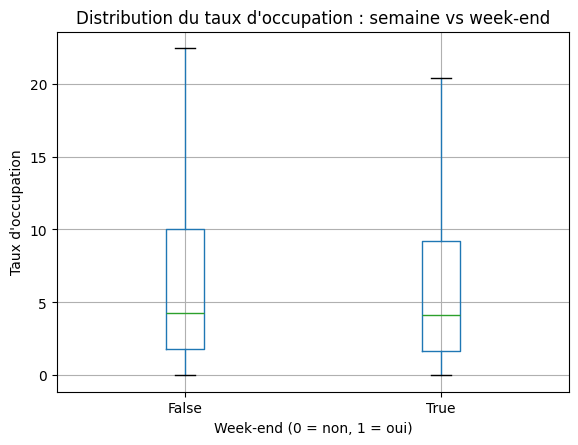

<Figure size 600x400 with 0 Axes>

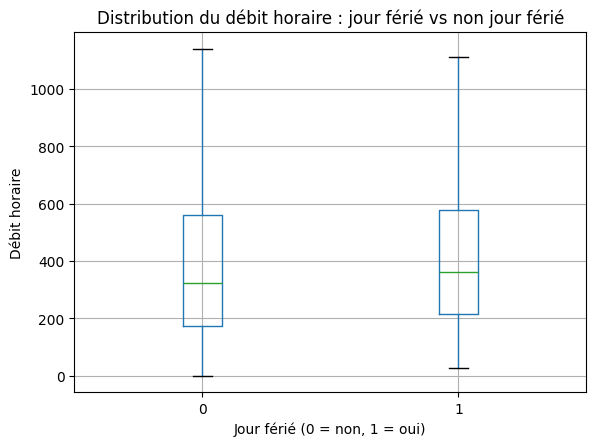

<Figure size 600x400 with 0 Axes>

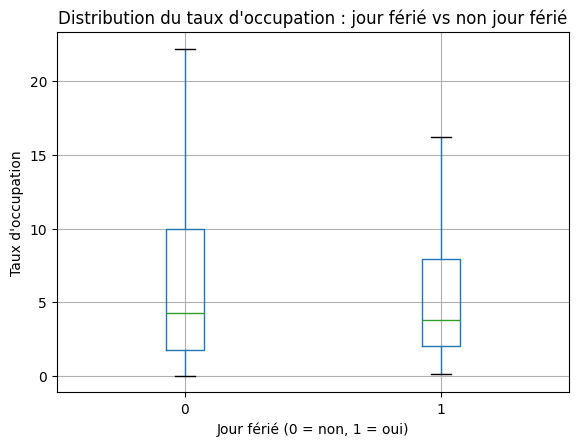

<Figure size 600x400 with 0 Axes>

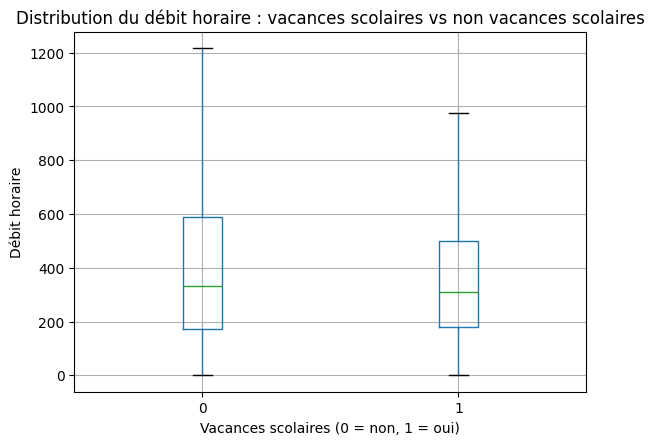

<Figure size 600x400 with 0 Axes>

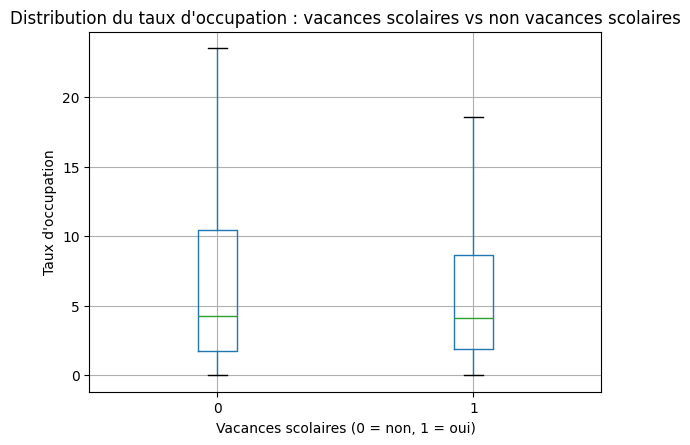

<Figure size 600x400 with 0 Axes>

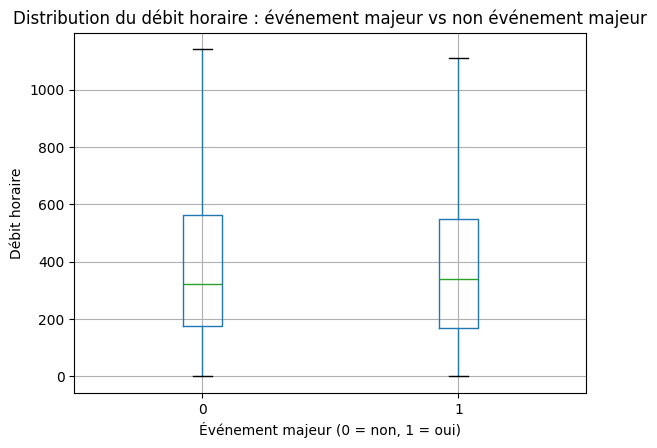

<Figure size 600x400 with 0 Axes>

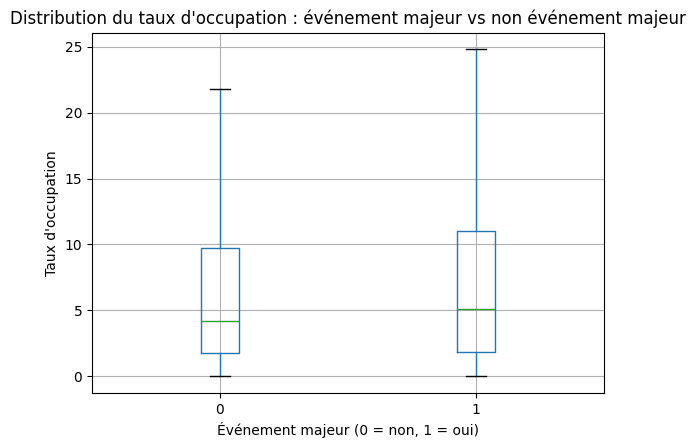

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_weekend',
    showfliers=False
)

plt.title('Distribution du débit horaire : semaine vs week-end')
plt.suptitle('')
plt.xlabel('Week-end (0 = non, 1 = oui)')
plt.ylabel('Débit horaire')
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_weekend',
    showfliers=False
)

plt.title("Distribution du taux d'occupation : semaine vs week-end")
plt.suptitle('')
plt.xlabel('Week-end (0 = non, 1 = oui)')
plt.ylabel("Taux d'occupation")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_jour_ferie',  
    showfliers=False
)   
plt.title('Distribution du débit horaire : jour férié vs non jour férié')
plt.suptitle('')
plt.xlabel('Jour férié (0 = non, 1 = oui)') 
plt.ylabel('Débit horaire')
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_jour_ferie',  
    showfliers=False
)   
plt.title("Distribution du taux d'occupation : jour férié vs non jour férié")
plt.suptitle('')
plt.xlabel('Jour férié (0 = non, 1 = oui)') 
plt.ylabel("Taux d'occupation")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_vacances_scolaires',   
    showfliers=False
)
plt.title('Distribution du débit horaire : vacances scolaires vs non vacances scolaires')   
plt.suptitle('')
plt.xlabel('Vacances scolaires (0 = non, 1 = oui)')
plt.ylabel('Débit horaire')
plt.show()  

plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_vacances_scolaires',   
    showfliers=False
)   
plt.title("Distribution du taux d'occupation : vacances scolaires vs non vacances scolaires")   
plt.suptitle('')    
plt.xlabel('Vacances scolaires (0 = non, 1 = oui)')
plt.ylabel("Taux d'occupation")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(
    column='Débit horaire',
    by='est_evenement_majeur',
    showfliers=False
)
plt.title('Distribution du débit horaire : événement majeur vs non événement majeur')   
plt.suptitle('')
plt.xlabel('Événement majeur (0 = non, 1 = oui)')
plt.ylabel('Débit horaire')
plt.show()  
plt.figure(figsize=(6,4))
df.boxplot(
    column="Taux d'occupation",
    by='est_evenement_majeur',
    showfliers=False
)
plt.title("Distribution du taux d'occupation : événement majeur vs non événement majeur")   
plt.suptitle('')    
plt.xlabel('Événement majeur (0 = non, 1 = oui)')
plt.ylabel("Taux d'occupation")
plt.show()  


<Figure size 800x500 with 0 Axes>

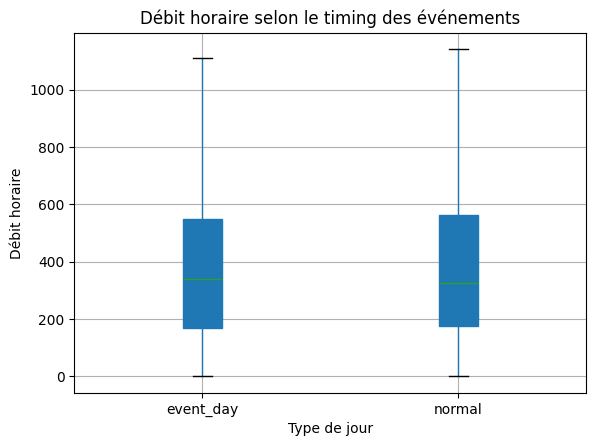

<Figure size 800x500 with 0 Axes>

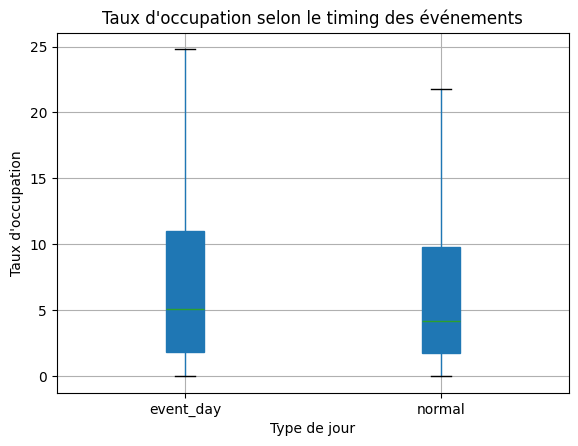

<Figure size 800x500 with 0 Axes>

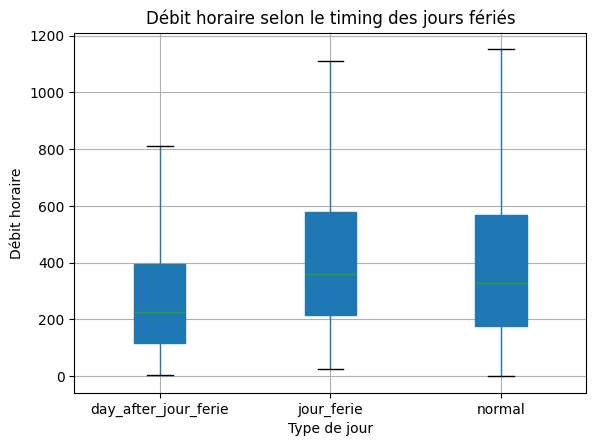

<Figure size 800x500 with 0 Axes>

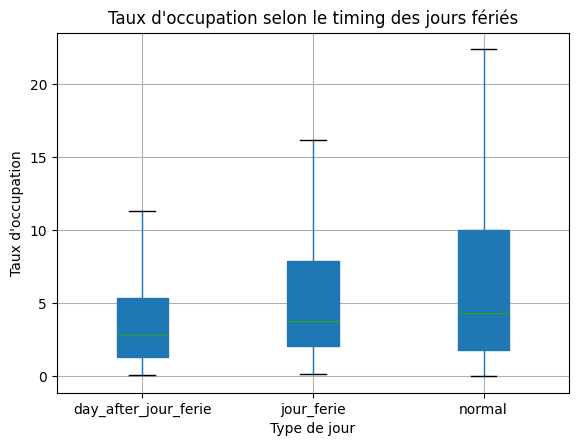

<Figure size 800x500 with 0 Axes>

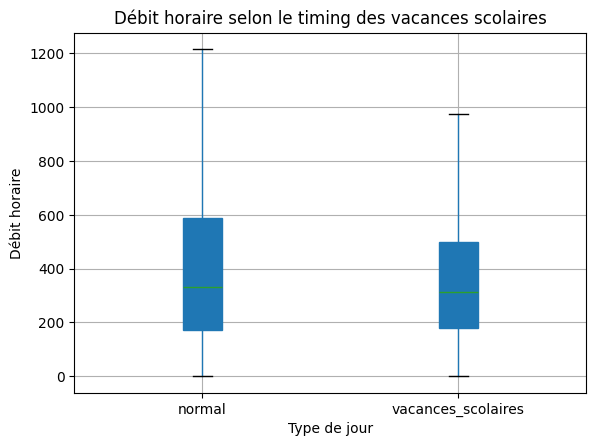

<Figure size 800x500 with 0 Axes>

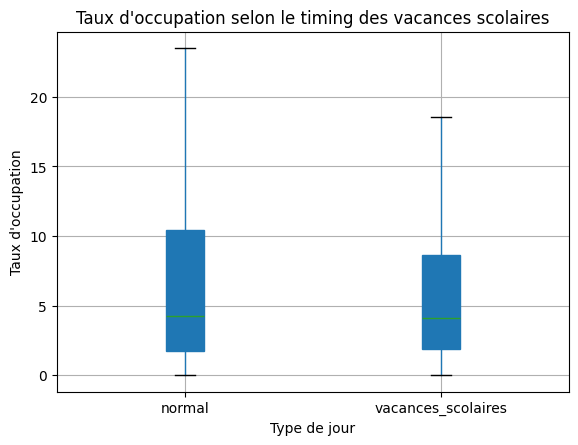

<Figure size 800x500 with 0 Axes>

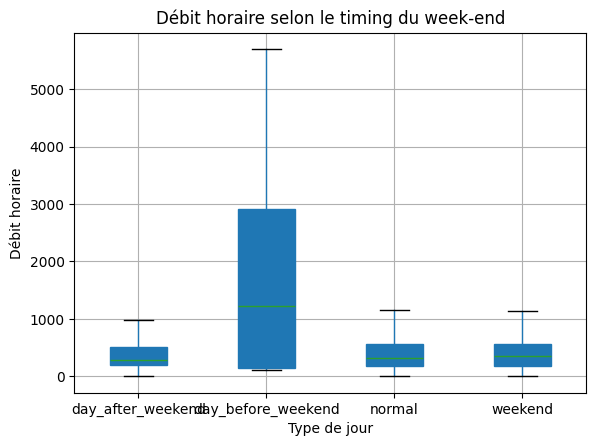

<Figure size 800x500 with 0 Axes>

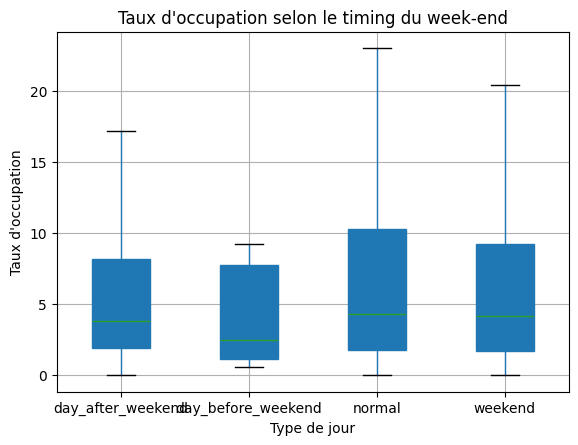

Script exécuté avec succès.


In [ ]:
# 事件前后影响 Analyse de l'impact avant et après les événements
df['event_timing'] = 'normal'  # 默认非事件
df.loc[df['est_evenement_majeur'] == 1, 'event_timing'] = 'event_day'
df.loc[df['est_evenement_majeur_day_before'] == 1, 'event_timing'] = 'day_before_event'
df.loc[df['est_evenement_majeur_day_after'] == 1, 'event_timing'] = 'day_after_event'
summary_event_timing = (
    df
    .groupby('event_timing')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='event_timing',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)
plt.title("Débit horaire selon le timing des événements")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel('Débit horaire')
plt.show()

plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='event_timing',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing des événements")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel("Taux d'occupation")
plt.show()

# 公共假日前后影响 Analyse de l'impact avant et après les jours fériés
df['jour_ferie_timing'] = 'normal'  # 默认非事件
df.loc[df['est_jour_ferie'] == 1, 'jour_ferie_timing'] = 'jour_ferie'
df.loc[df['est_jour_ferie_day_before'] == 1, 'jour_ferie_timing'] = 'day_before_jour_ferie'
df.loc[df['est_jour_ferie_day_after'] == 1, 'jour_ferie_timing'] = 'day_after_jour_ferie'
summary_jour_ferie_timing = (
    df.groupby('jour_ferie_timing')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='jour_ferie_timing',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)   
plt.title("Débit horaire selon le timing des jours fériés")
plt.suptitle('')
plt.xlabel('Type de jour')  
plt.ylabel('Débit horaire')
plt.show()
plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='jour_ferie_timing',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing des jours fériés")
plt.suptitle('')
plt.xlabel('Type de jour')  
plt.ylabel("Taux d'occupation")
plt.show()

# 学生假日前后影响 Analyse de l'impact avant et après les vacances scolaires
df['vacance_timing'] = 'normal'  # 默认非事件
df.loc[df['est_vacances_scolaires'] == 1, 'vacance_timing'] = 'vacances_scolaires'
df.loc[df['est_vacances_scolaires_day_before'] == 1, 'vacance_timing'] = 'day_before_vacances_scolaires'
df.loc[df['est_vacances_scolaires_day_after'] == 1, 'vacance_timing'] = 'day_after_vacances_scolaires'
summary_vacance_timing = ( 
    df.groupby('vacance_timing')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='vacance_timing',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)
plt.title("Débit horaire selon le timing des vacances scolaires")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel('Débit horaire')
plt.show()
plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='vacance_timing',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing des vacances scolaires")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel("Taux d'occupation")
plt.show()

# 周末前后影响 Analyse de l'impact avant et après les week-ends
df['weekend_time'] = 'normal'  # 默认非事件
df.loc[df['est_weekend'] == 1, 'weekend_time'] = 'weekend'
df.loc[df['est_weekend_day_before'] == 1, 'weekend_time'] = 'day_before_weekend'
df.loc[df['est_weekend_day_after'] == 1, 'weekend_time'] = 'day_after_weekend'
summary_weekend_time = (   
    df.groupby('weekend_time')
    .agg(
        debit_count=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_count=('Taux d\'occupation', 'count'),
        occupation_mean=('Taux d\'occupation', 'mean'),
        occupation_median=('Taux d\'occupation', 'median'),
        occupation_p25=('Taux d\'occupation', lambda x: x.quantile(0.25)),
        occupation_p75=('Taux d\'occupation', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
plt.figure(figsize=(8,5))
df.boxplot(
    column='Débit horaire',
    by='weekend_time',
    showfliers=False,   # 隐藏异常值
    patch_artist=True   # 填充颜色
)
plt.title("Débit horaire selon le timing du week-end")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel('Débit horaire')
plt.show()
plt.figure(figsize=(8,5))
df.boxplot(
    column="Taux d'occupation",
    by='weekend_time',
    showfliers=False,
    patch_artist=True
)
plt.title("Taux d'occupation selon le timing du week-end")
plt.suptitle('')
plt.xlabel('Type de jour')
plt.ylabel("Taux d'occupation")
plt.show()
print("Script exécuté avec succès.")

In [20]:
summary_weekend_time

,weekend_time,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,day_after_weekend,1032,584.007558,288.0,187.75,506.50,1032,6.698633,3.814170,1.900003,8.150560
1,day_before_weekend,16,1957.250000,1230.5,141.00,2915.00,20,5.850390,2.450000,1.139447,7.750000
2,normal,11029,645.544564,323.0,173.00,566.00,11626,8.600859,4.323055,1.778747,10.280558
3,weekend,3360,774.043065,344.5,176.00,566.25,3391,7.800439,4.142220,1.679725,9.200835


In [21]:
summary_event_timing

,event_timing,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,event_day,1191,497.151385,340.0,169.0,549.5,1173,9.214767,5.11611,1.846110,11.035000
1,normal,14246,685.273073,324.0,176.0,563.0,14896,8.234825,4.19834,1.763193,9.766807


In [22]:
summary_vacance_timing

,vacance_timing,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,normal,10951,726.714181,332.2,172.0,590.0,11637,8.601869,4.28945,1.718890,10.440560
1,vacances_scolaires,4486,534.164177,311.5,180.0,498.0,4432,7.530442,4.10389,1.898192,8.618335


In [23]:
summary_jour_ferie_timing

,jour_ferie_timing,debit_count,debit_mean,debit_median,debit_p25,debit_p75,occupation_count,occupation_mean,occupation_median,occupation_p25,occupation_p75
0,day_after_jour_ferie,531,283.956685,226.0,116.5,394.00,433,7.085783,2.79389,1.333330,5.355000
1,jour_ferie,486,436.207819,361.5,215.0,578.75,473,7.660131,3.79000,2.043340,7.923330
2,normal,14420,692.907732,329.5,178.0,568.00,15163,8.361372,4.33500,1.785835,10.055555


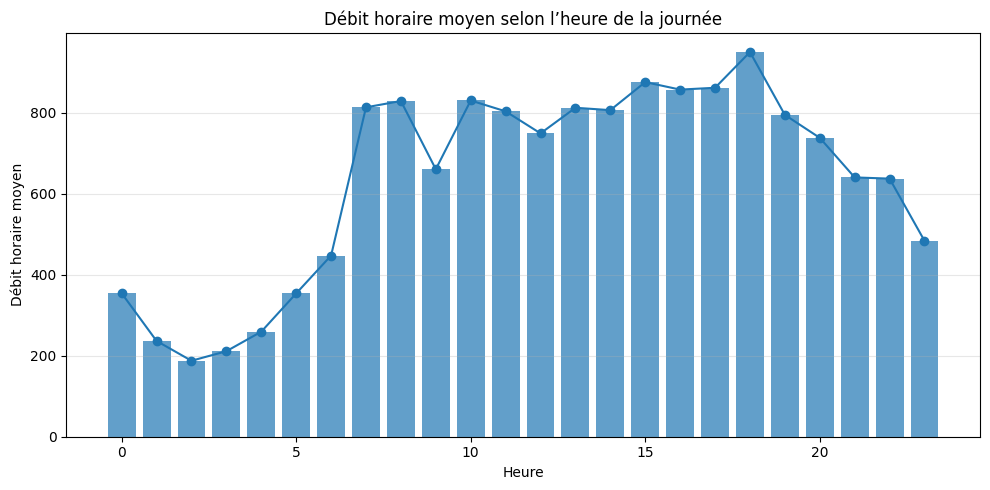

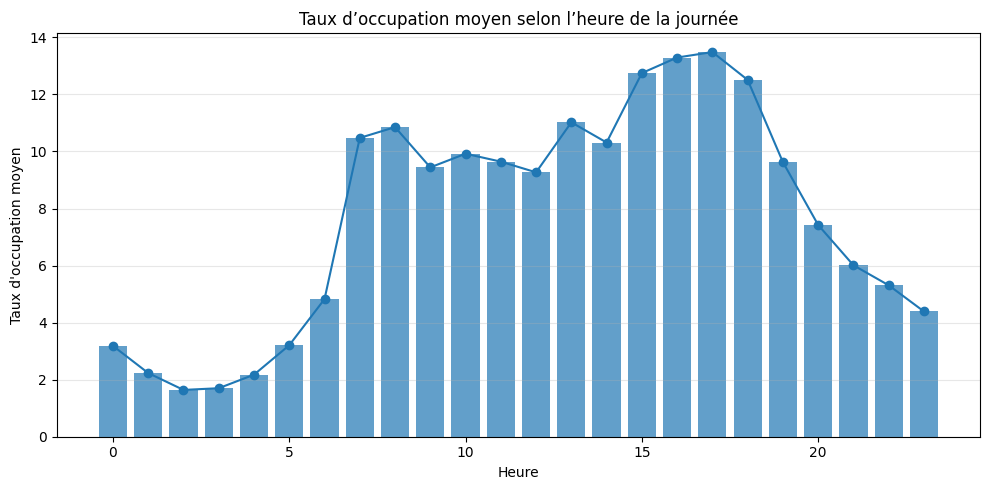

In [26]:
import matplotlib.pyplot as plt

def bar_line_plot(x, y, xlabel, ylabel, title, xticklabels=None):
    plt.figure(figsize=(10,5))

    # bar
    plt.bar(x, y, alpha=0.7)

    # line (same values)
    plt.plot(x, y, marker='o')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    if xticklabels is not None:
        plt.xticks(x, xticklabels)

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

df['heure'] = df['Date et heure de comptage'].dt.hour

hourly_mean = (
    df.groupby('heure')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
)

bar_line_plot(
    x=hourly_mean.index,
    y=hourly_mean['debit_mean'],
    xlabel="Heure",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon l’heure de la journée"
)

bar_line_plot(
    x=hourly_mean.index,
    y=hourly_mean['occupation_mean'],
    xlabel="Heure",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon l’heure de la journée"
)


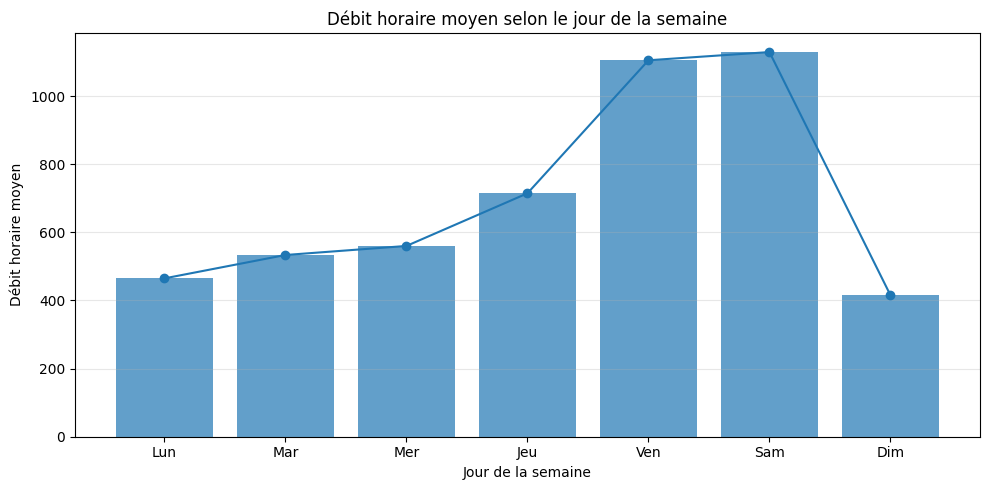

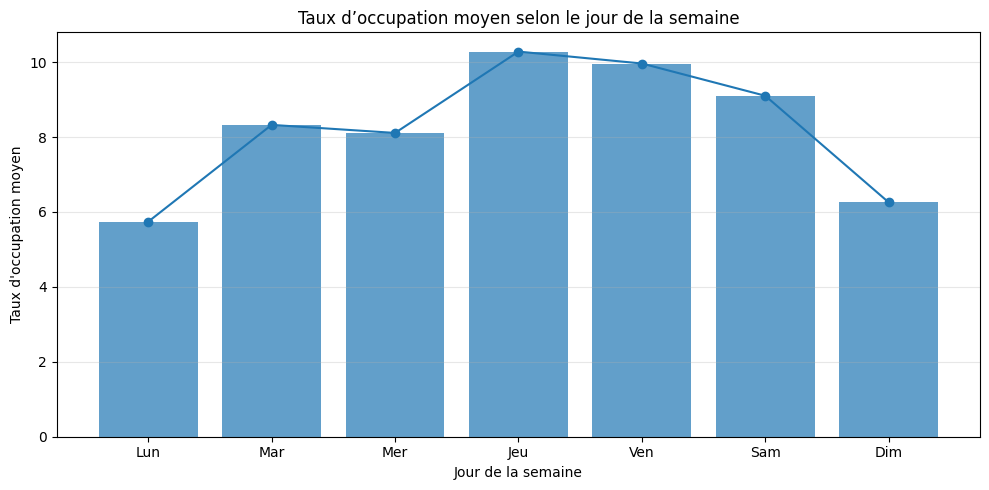

In [27]:
weekday_mean = (
    df.groupby('weekday')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
)

weekday_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
bar_line_plot(
    x=weekday_mean.index,
    y=weekday_mean['debit_mean'],
    xlabel="Jour de la semaine",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon le jour de la semaine",
    xticklabels=weekday_labels
)
bar_line_plot(
    x=weekday_mean.index,
    y=weekday_mean['occupation_mean'],
    xlabel="Jour de la semaine",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon le jour de la semaine",
    xticklabels=weekday_labels
)

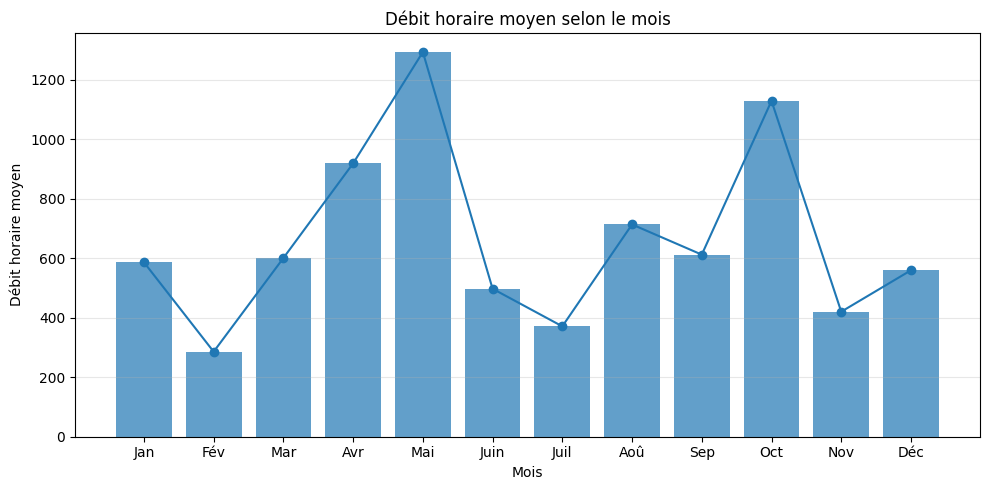

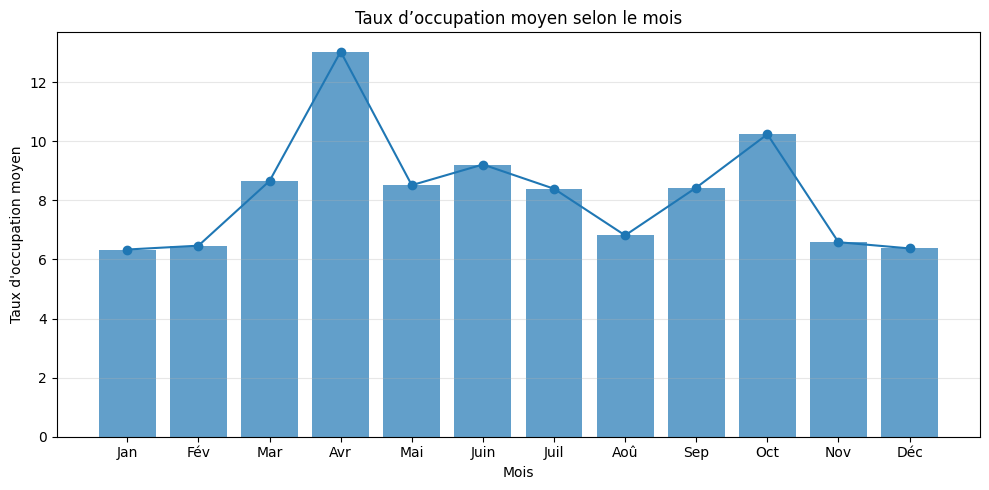

In [28]:
monthly_mean = (
    df.groupby('mois')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
)
month_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
bar_line_plot(
    x=monthly_mean.index,
    y=monthly_mean['debit_mean'],
    xlabel="Mois",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon le mois",
    xticklabels=month_labels
)
bar_line_plot(
    x=monthly_mean.index,
    y=monthly_mean['occupation_mean'],
    xlabel="Mois",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon le mois",
    xticklabels=month_labels
)

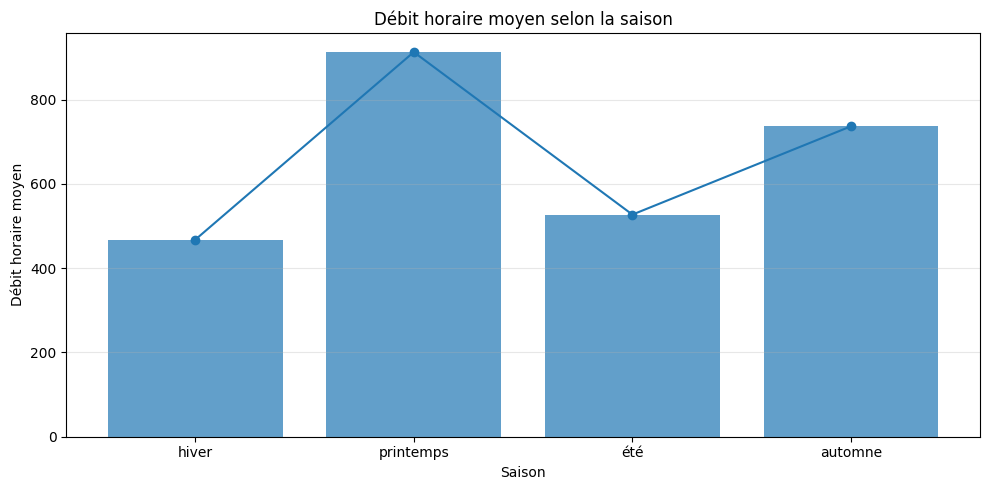

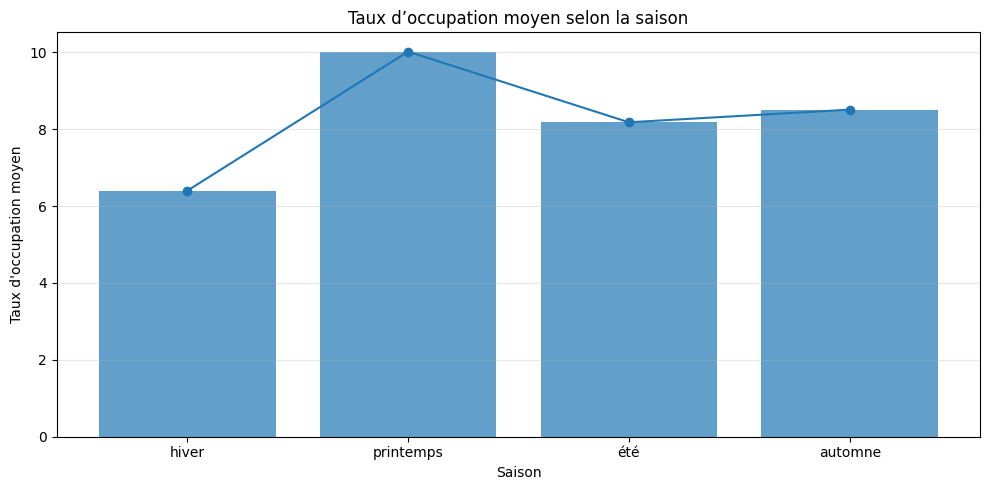

In [29]:
season_order = ['hiver', 'printemps', 'été', 'automne']

season_mean = (
    df.groupby('saison')
      .agg(
          debit_mean=('Débit horaire', 'mean'),
          occupation_mean=("Taux d'occupation", 'mean')
      )
      .reindex(season_order)
)
bar_line_plot(
    x=season_mean.index,
    y=season_mean['debit_mean'],
    xlabel="Saison",
    ylabel="Débit horaire moyen",
    title="Débit horaire moyen selon la saison"
)
bar_line_plot(
    x=season_mean.index,
    y=season_mean['occupation_mean'],
    xlabel="Saison",
    ylabel="Taux d'occupation moyen",
    title="Taux d’occupation moyen selon la saison"
)

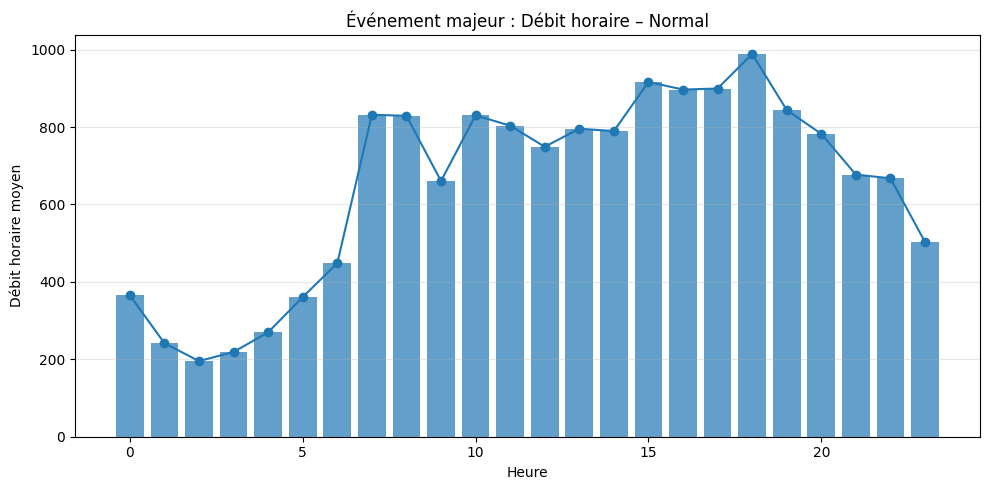

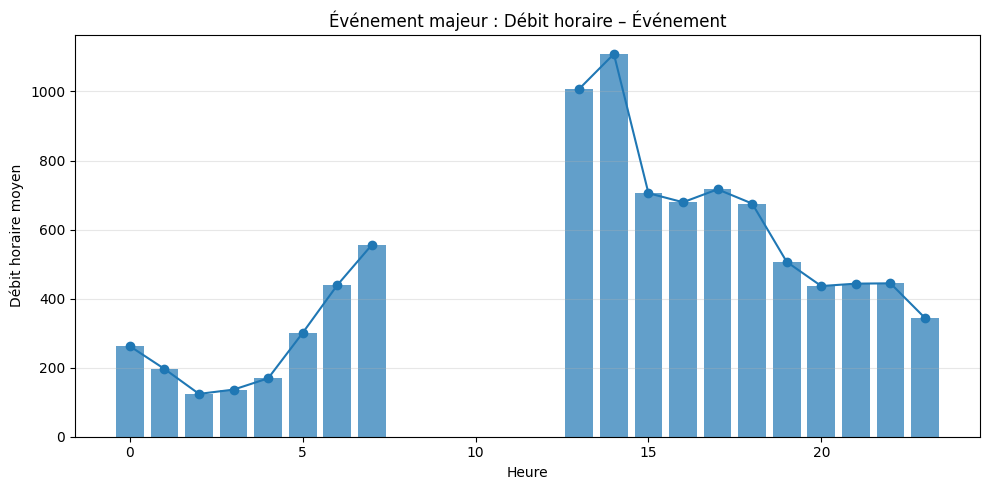

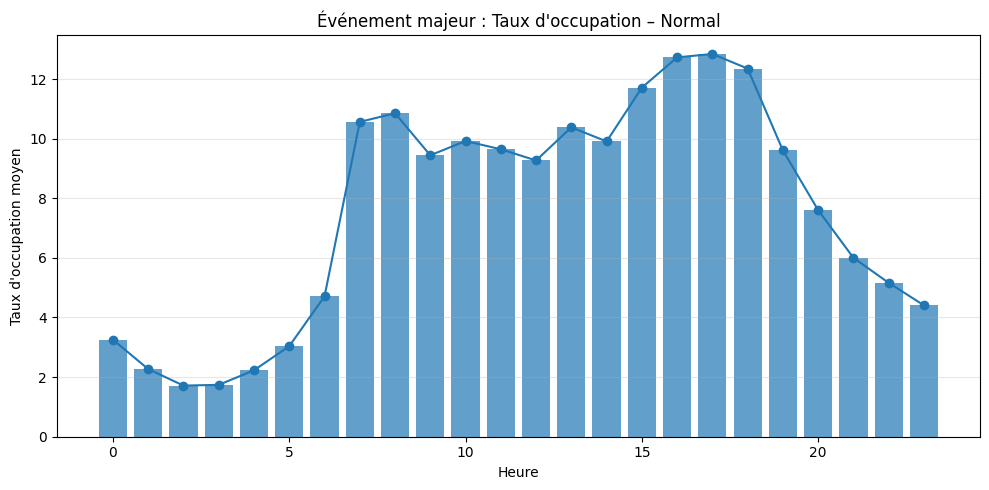

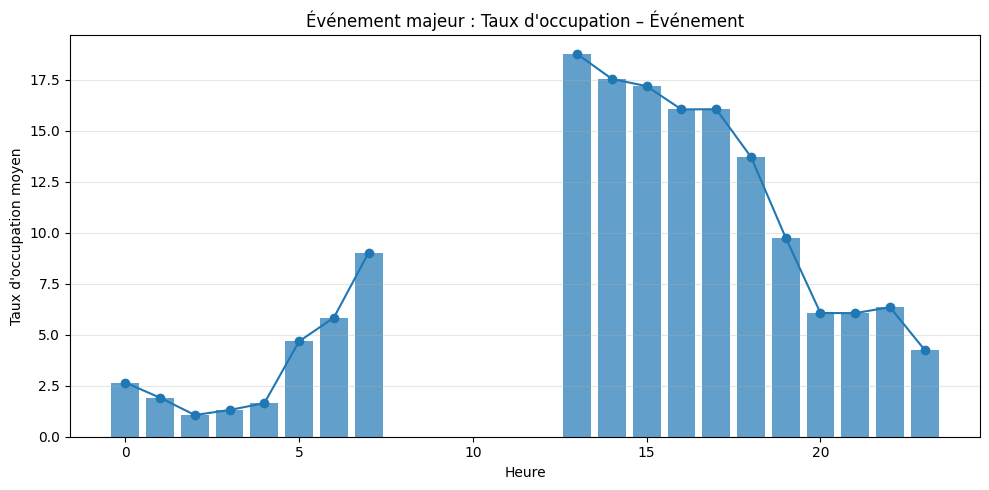

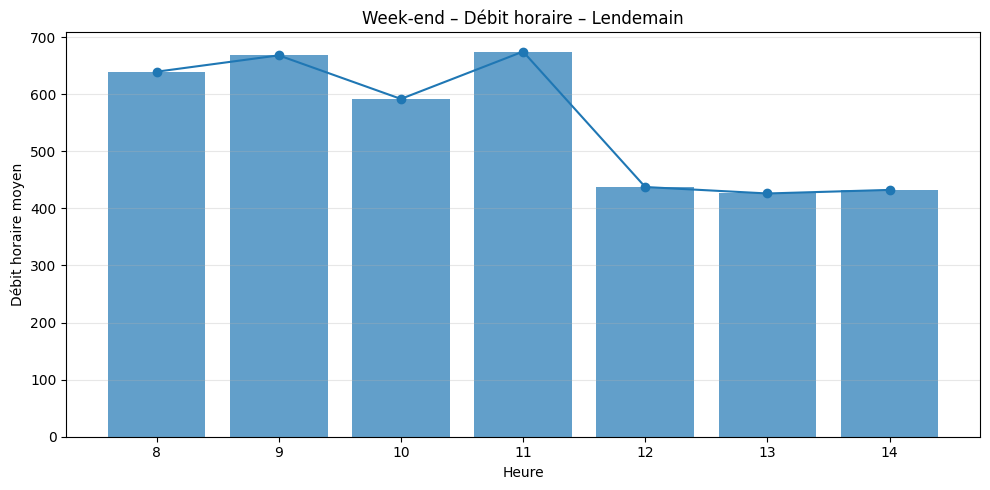

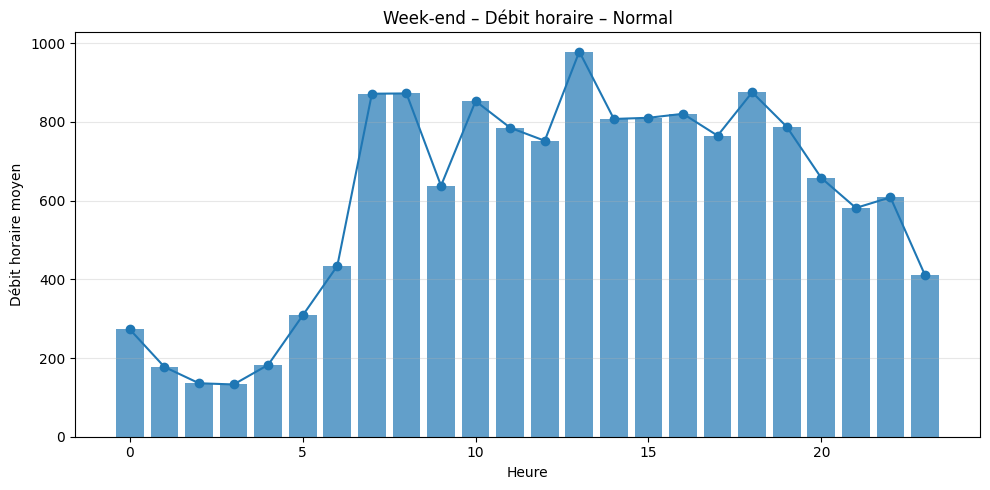

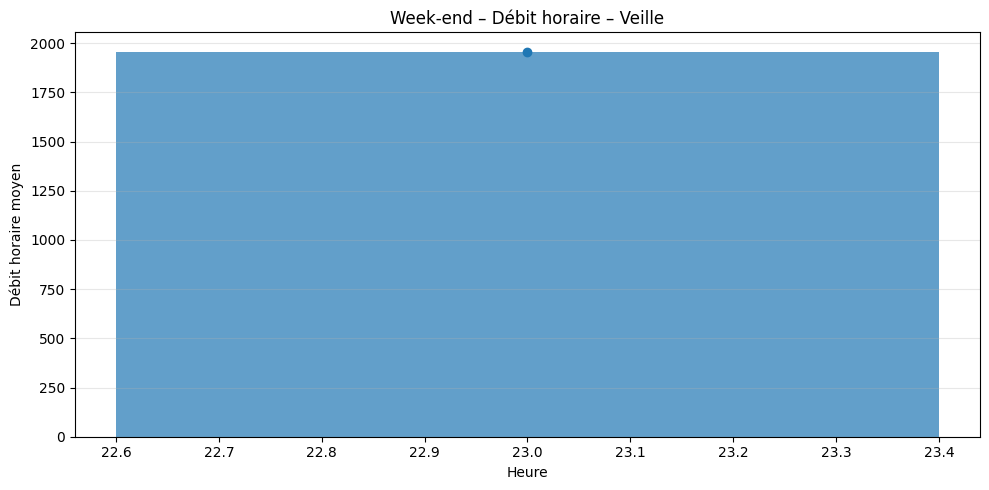

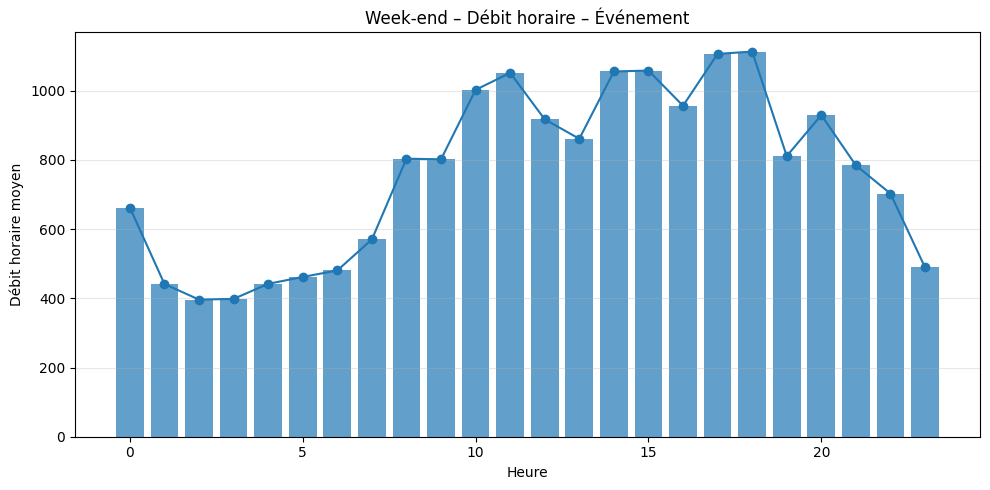

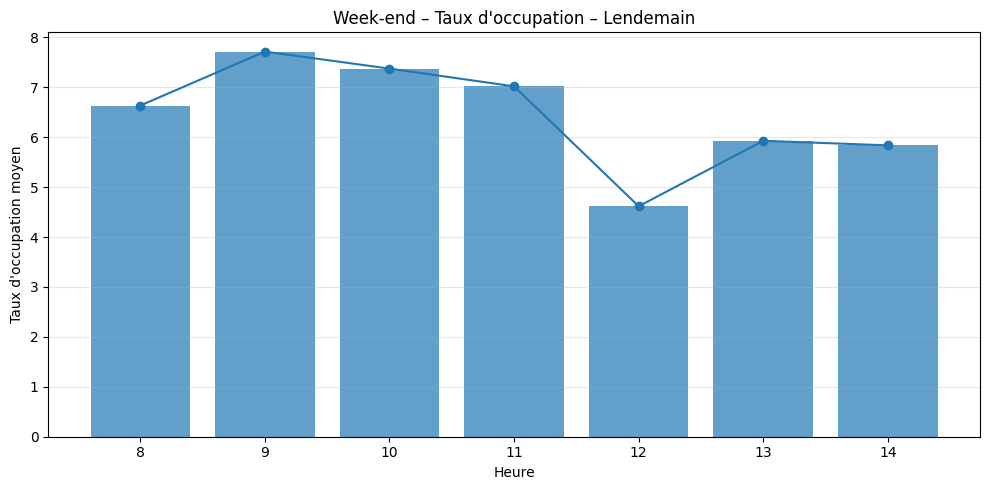

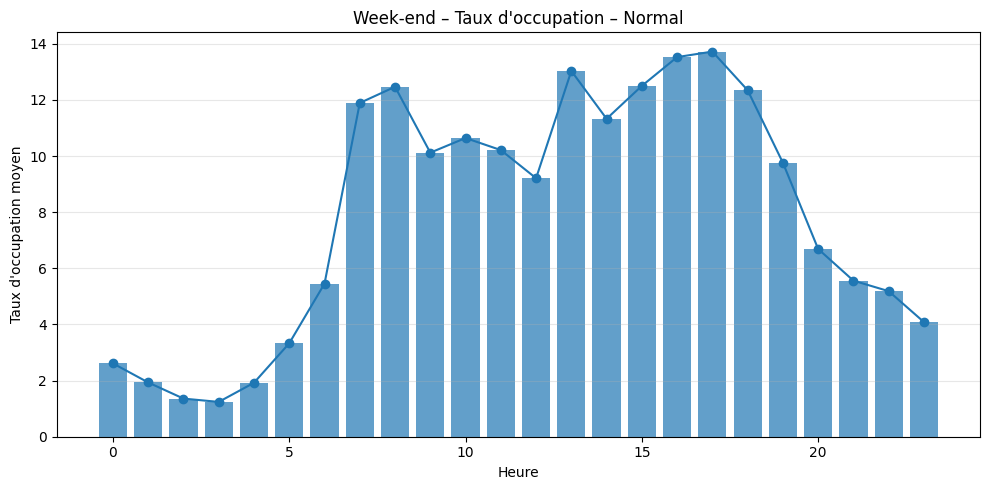

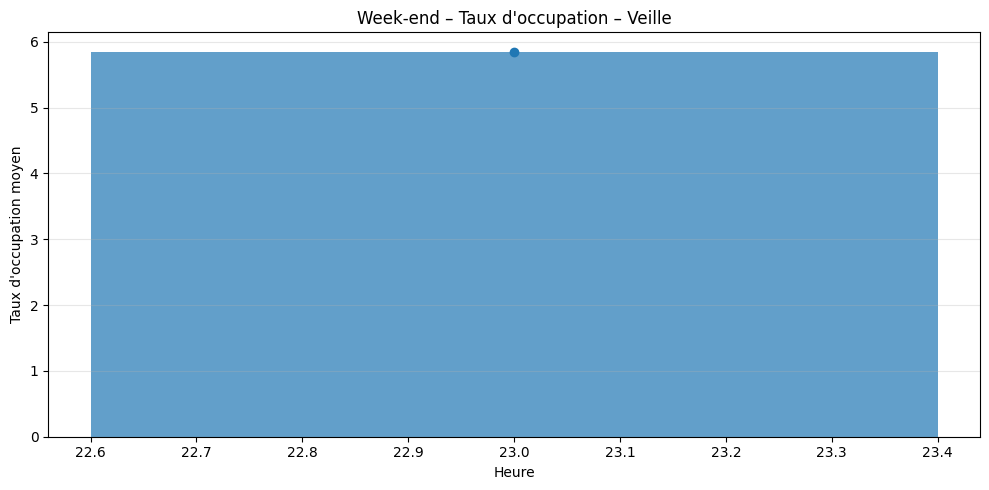

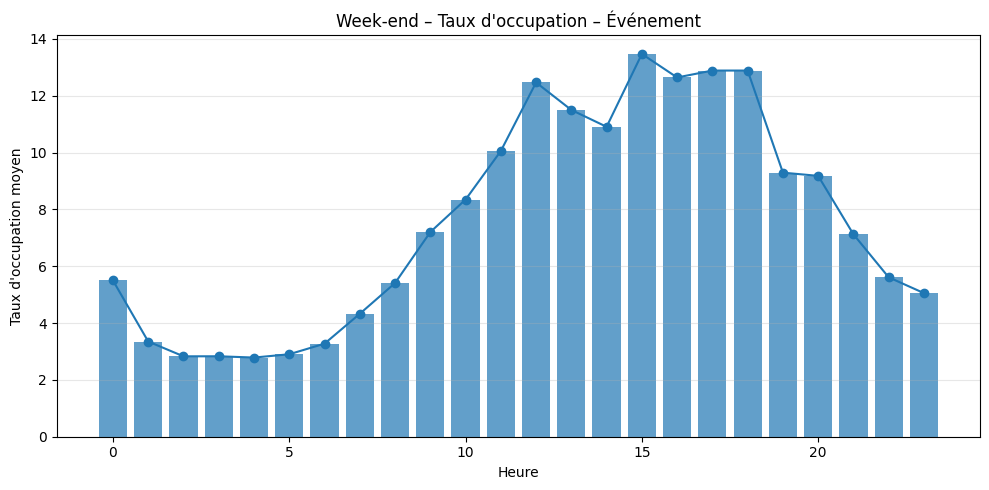

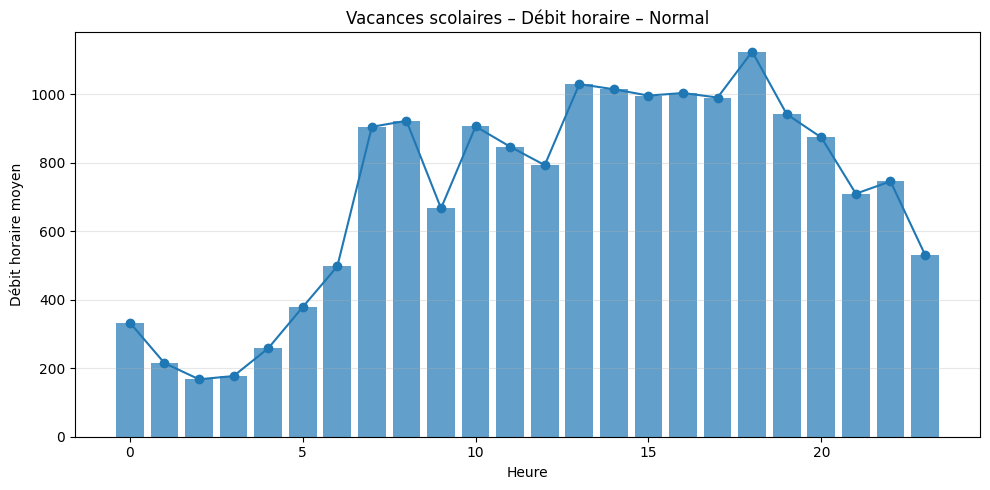

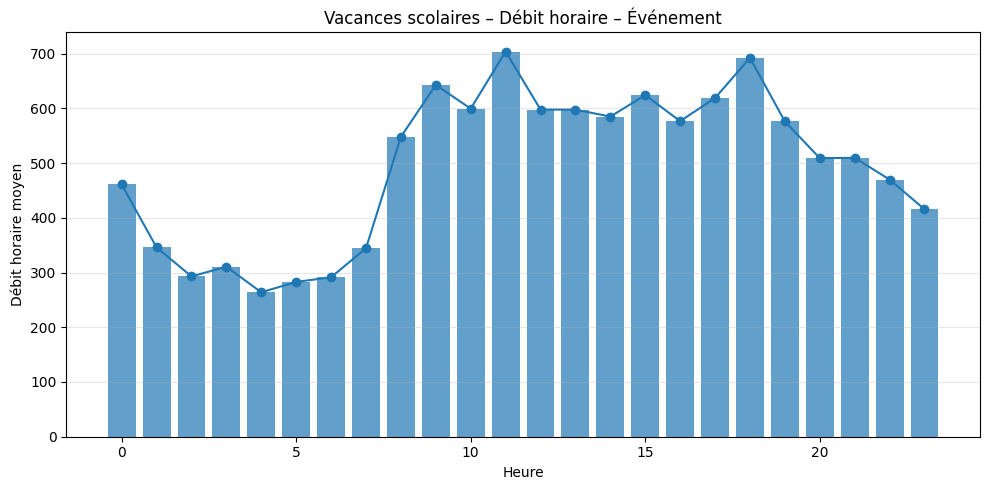

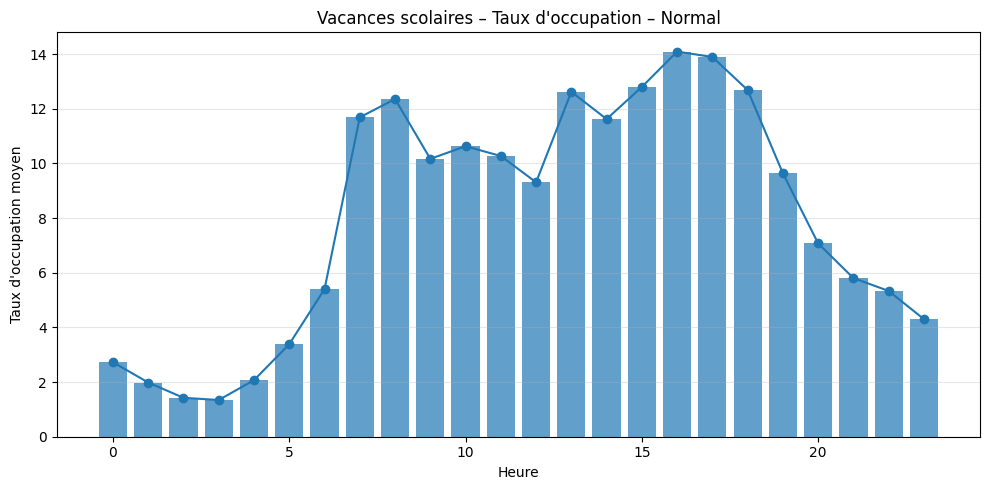

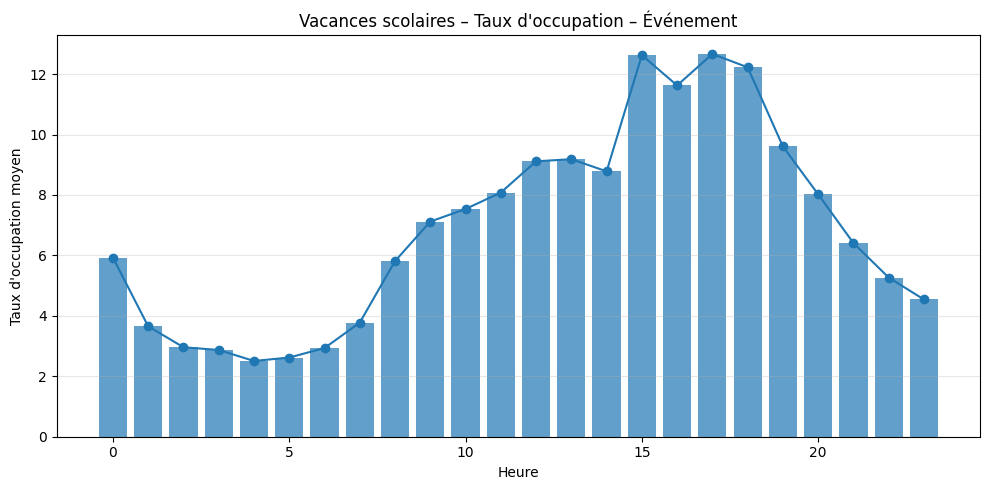

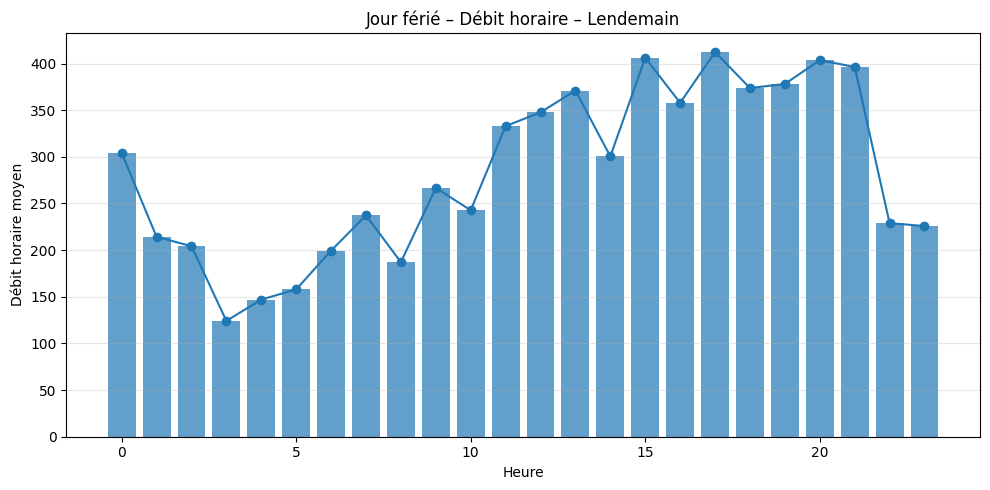

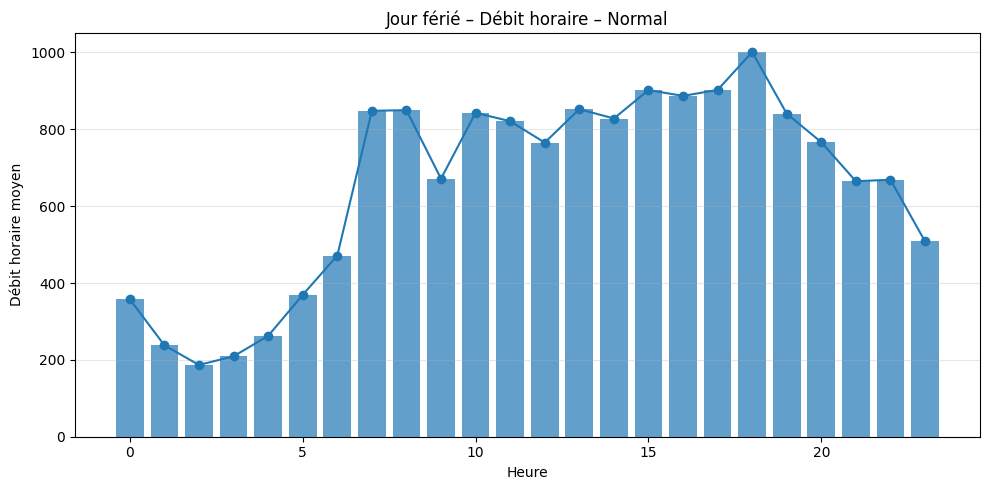

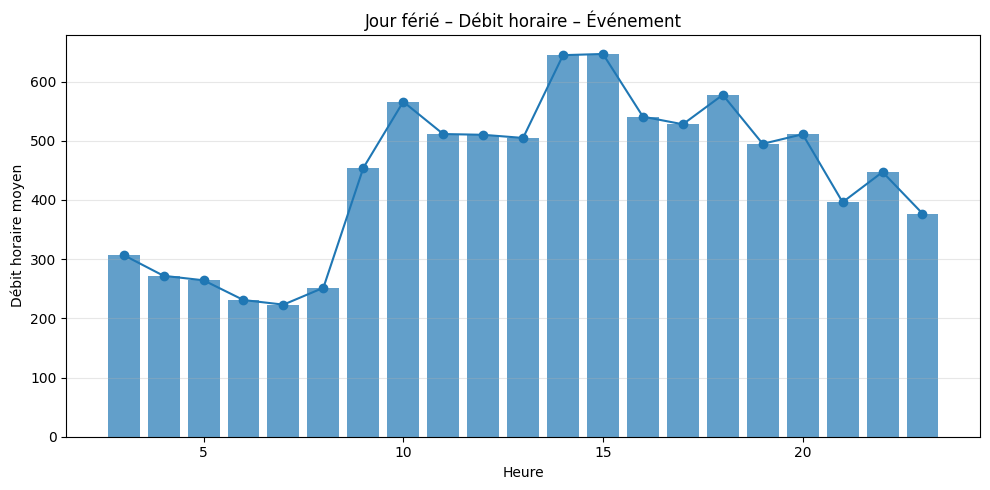

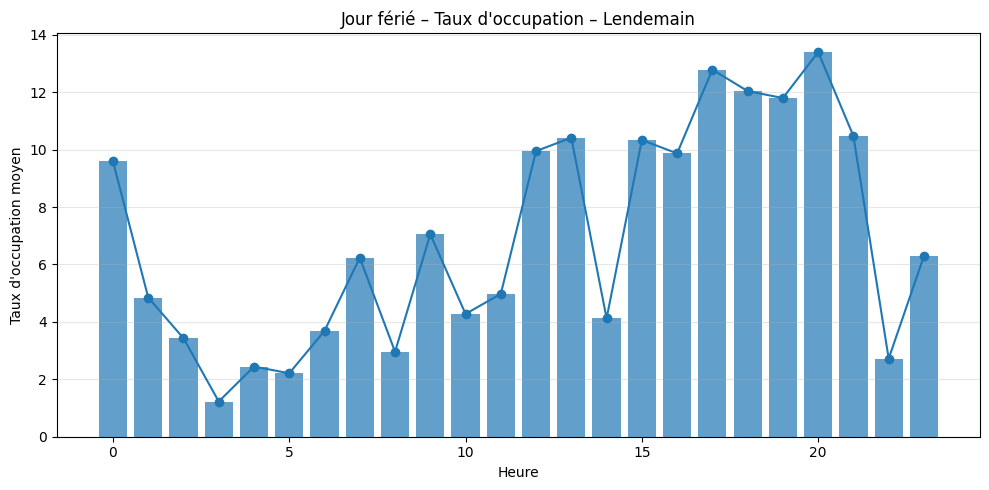

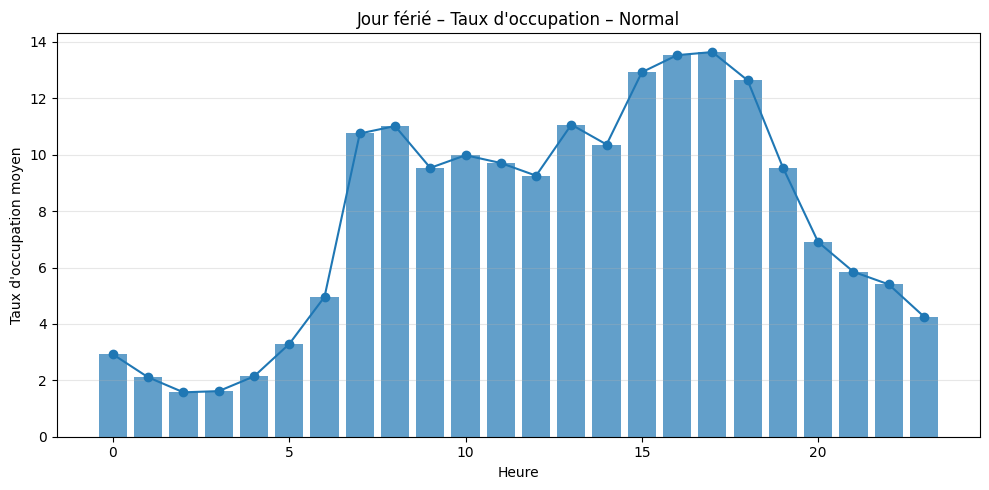

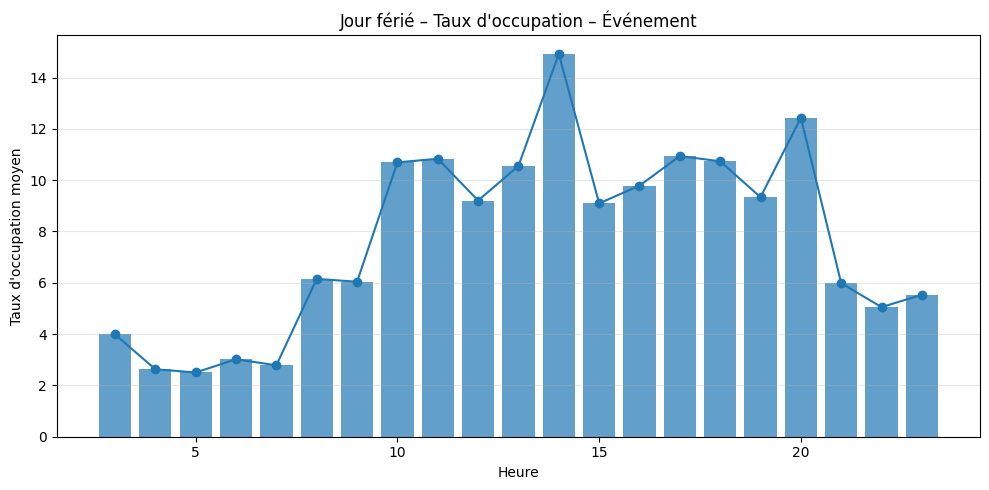

In [30]:
def plot_event_hourly_profile(
    df,
    event_prefix,
    value_col,
    title_prefix=""
):
    """
    df : DataFrame
    event_prefix : str, e.g. 'est_weekend'
    value_col : 'Débit horaire' or "Taux d'occupation"
    """

    df_tmp = df.copy()

    # 统一 phase
    phase_col = f'phase_{event_prefix}'
    df_tmp[phase_col] = 'Normal'

    df_tmp.loc[df_tmp[f'{event_prefix}_day_before'] == 1, phase_col] = 'Veille'
    df_tmp.loc[df_tmp[event_prefix] == 1, phase_col] = 'Événement'
    df_tmp.loc[df_tmp[f'{event_prefix}_day_after'] == 1, phase_col] = 'Lendemain'

    # 只保留有数据的 phase
    hourly_mean = (
        df_tmp
        .groupby(['heure', phase_col])[value_col]
        .mean()
        .unstack()
        .dropna(axis=1, how='all')
    )

    # 绘图
    for phase in hourly_mean.columns:
        bar_line_plot(
            x=hourly_mean.index,
            y=hourly_mean[phase],
            xlabel="Heure",
            ylabel=f"{value_col} moyen",
            title=f"{title_prefix}{value_col} – {phase}"
        )
plot_event_hourly_profile(
    df,
    event_prefix='est_evenement_majeur',
    value_col='Débit horaire', 
    title_prefix="Événement majeur : "
)
plot_event_hourly_profile(
    df,
    event_prefix='est_evenement_majeur',
    value_col="Taux d'occupation", 
    title_prefix="Événement majeur : "  
)

plot_event_hourly_profile(
    df,
    event_prefix='est_weekend',
    value_col='Débit horaire',
    title_prefix='Week-end – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_weekend',
    value_col="Taux d'occupation",
    title_prefix='Week-end – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_vacances_scolaires',
    value_col='Débit horaire',
    title_prefix='Vacances scolaires – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_vacances_scolaires',
    value_col="Taux d'occupation",
    title_prefix='Vacances scolaires – '
)

plot_event_hourly_profile(
    df,
    event_prefix='est_jour_ferie',
    value_col='Débit horaire',
    title_prefix='Jour férié – '
)   
plot_event_hourly_profile(
    df,
    event_prefix='est_jour_ferie',
    value_col="Taux d'occupation",
    title_prefix='Jour férié – '
)